In [17]:
import sys
sys.path.append('../src')

from preprocessing import cut_isEMTight, cut_pt, cut_eta
import uproot
import awkward as ak
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [18]:
file = uproot.open('../data/raw/higgs/DAOD_PHYSLITE.38191914._000036.pool.root (1).1') #open the root file
tree = file['CollectionTree']


In [19]:
pt = tree["AnalysisPhotonsAuxDyn.pt"].array()
eta = tree["AnalysisPhotonsAuxDyn.eta"].array()
phi = tree["AnalysisPhotonsAuxDyn.phi"].array()

ptcone20 = tree["AnalysisPhotonsAuxDyn.ptcone20_CloseByCorr"].array()
topoetcone20 = tree["AnalysisPhotonsAuxDyn.topoetcone20_CloseByCorr"].array()
topoetcone40 = tree["AnalysisPhotonsAuxDyn.topoetcone40_CloseByCorr"].array()

f1 = tree["AnalysisPhotonsAuxDyn.f1"].array()


isEMTight = tree["AnalysisPhotonsAuxDyn.DFCommonPhotonsIsEMTight"].array()

truthOrigin = tree["AnalysisPhotonsAuxDyn.truthOrigin"].array()


print(f"Number of events before cuts: {len(pt)}")

Number of events before cuts: 200000


In [20]:
# isEMTight cut

tight_mask = cut_isEMTight(isEMTight)

pt = pt[tight_mask]
eta = eta[tight_mask]
phi = phi[tight_mask]
ptcone20 = ptcone20[tight_mask]
topoetcone20 = topoetcone20[tight_mask]
topoetcone40 = topoetcone40[tight_mask]
f1 = f1[tight_mask]
truthOrigin = truthOrigin[tight_mask]

In [21]:
# at least 2 tight photons

n_photons = ak.num(pt)
has_2plus = (n_photons >= 2)

pt = pt[has_2plus]
eta = eta[has_2plus]
phi = phi[has_2plus]
ptcone20 = ptcone20[has_2plus]
topoetcone20 = topoetcone20[has_2plus]
topoetcone40 = topoetcone40[has_2plus]
f1 = f1[has_2plus]
truthOrigin = truthOrigin[has_2plus]

print(f"Number of events after requiring at least 2 tight photons: {len(pt)}")

Number of events after requiring at least 2 tight photons: 113624


In [22]:
# lead/sublead pt cuts
sorted_indices = ak.argsort(pt, axis=1, ascending=False)

pt_sorted = pt[sorted_indices]
eta_sorted = eta[sorted_indices]
phi_sorted = phi[sorted_indices]
ptcone20_sorted = ptcone20[sorted_indices]
topoetcone20_sorted = topoetcone20[sorted_indices]
topoetcone40_sorted = topoetcone40[sorted_indices]
f1_sorted = f1[sorted_indices]
truthOrigin_sorted = truthOrigin[sorted_indices]

#Lead photons
pt_lead = pt_sorted[:, 0]
eta_lead = eta_sorted[:, 0]
phi_lead = phi_sorted[:, 0]
ptcone20_lead = ptcone20_sorted[:, 0]
topoetcone20_lead = topoetcone20_sorted[:, 0]
topoetcone40_lead = topoetcone40_sorted[:, 0]
f1_lead = f1_sorted[:, 0]
truthOrigin_lead = truthOrigin_sorted[:, 0]

#Sublead photons
pt_sublead = pt_sorted[:, 1]
eta_sublead = eta_sorted[:, 1]
phi_sublead = phi_sorted[:, 1]
ptcone20_sublead = ptcone20_sorted[:, 1]
topoetcone20_sublead = topoetcone20_sorted[:, 1]
topoetcone40_sublead = topoetcone40_sorted[:, 1]
f1_sublead = f1_sorted[:, 1]
truthOrigin_sublead = truthOrigin_sorted[:, 1]



In [23]:
# pt cut

pt_cut = cut_pt(pt_lead, pt_sublead)

pt_lead = pt_lead[pt_cut]
pt_sublead = pt_sublead[pt_cut]
eta_lead = eta_lead[pt_cut]
eta_sublead = eta_sublead[pt_cut]
phi_lead = phi_lead[pt_cut]
phi_sublead = phi_sublead[pt_cut]
ptcone20_lead = ptcone20_lead[pt_cut]
ptcone20_sublead = ptcone20_sublead[pt_cut]
topoetcone20_lead = topoetcone20_lead[pt_cut]
topoetcone20_sublead = topoetcone20_sublead[pt_cut]
topoetcone40_lead = topoetcone40_lead[pt_cut]
topoetcone40_sublead = topoetcone40_sublead[pt_cut]
f1_lead = f1_lead[pt_cut]
f1_sublead = f1_sublead[pt_cut]
truthOrigin_lead = truthOrigin_lead[pt_cut]
truthOrigin_sublead = truthOrigin_sublead[pt_cut]

print(f"Number of events after lead/sublead pt cuts: {len(pt_lead)}")

Number of events after lead/sublead pt cuts: 78666


In [24]:
# eta cut

eta_cut = cut_eta(eta_lead, eta_sublead)

pt_lead = pt_lead[eta_cut]
pt_sublead = pt_sublead[eta_cut]
eta_lead = eta_lead[eta_cut]
eta_sublead = eta_sublead[eta_cut]
phi_lead = phi_lead[eta_cut]
phi_sublead = phi_sublead[eta_cut]
ptcone20_lead = ptcone20_lead[eta_cut]
ptcone20_sublead = ptcone20_sublead[eta_cut]
topoetcone20_lead = topoetcone20_lead[eta_cut]
topoetcone20_sublead = topoetcone20_sublead[eta_cut]
topoetcone40_lead = topoetcone40_lead[eta_cut]
topoetcone40_sublead = topoetcone40_sublead[eta_cut]
f1_lead = f1_lead[eta_cut]
f1_sublead = f1_sublead[eta_cut]
truthOrigin_lead = truthOrigin_lead[eta_cut]
truthOrigin_sublead = truthOrigin_sublead[eta_cut]

print(f"Number of events after eta cuts: {len(pt_lead)}")

Number of events after eta cuts: 78112


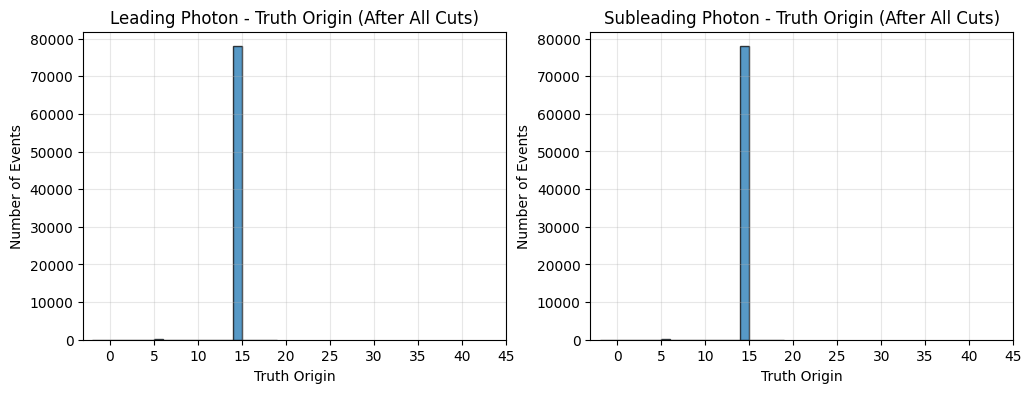

In [29]:
#Leading photon truthOrigin distribution

plt.figure(figsize=(12,4))
plt.subplot(1, 2, 1)
truthOrigin_lead_np = ak.to_numpy(truthOrigin_lead)
plt.hist(truthOrigin_lead_np, bins= range(-2, 20,1), edgecolor='black', alpha=0.75)
plt.title('Leading Photon - Truth Origin (After All Cuts)')
plt.xlabel('Truth Origin')
plt.ylabel('Number of Events')
plt.xticks(range(0, 46, 5))
plt.grid(alpha=0.3)

# Subleading photon truthOrigin distribution
plt.subplot(1, 2, 2)
truthOrigin_sublead_np = ak.to_numpy(truthOrigin_sublead)
plt.hist(truthOrigin_sublead_np, bins= range(-2, 20,1), edgecolor='black', alpha=0.75)
plt.title('Subleading Photon - Truth Origin (After All Cuts)')
plt.xlabel('Truth Origin')
plt.ylabel('Number of Events')
plt.xticks(range(0, 46, 5))
plt.grid(alpha=0.3)
plt.show()

In [26]:
higgs_df = pd.DataFrame({
    'pt_lead': ak.to_numpy(pt_lead),
    'pt_sublead': ak.to_numpy(pt_sublead),
    'eta_lead': ak.to_numpy(eta_lead),
    'eta_sublead': ak.to_numpy(eta_sublead),
    'phi_lead': ak.to_numpy(phi_lead),
    'phi_sublead': ak.to_numpy(phi_sublead),
    'ptcone20_lead': ak.to_numpy(ptcone20_lead),
    'ptcone20_sublead': ak.to_numpy(ptcone20_sublead),
    'topoetcone20_lead': ak.to_numpy(topoetcone20_lead),
    'topoetcone20_sublead': ak.to_numpy(topoetcone20_sublead),
    'topoetcone40_lead': ak.to_numpy(topoetcone40_lead),
    'topoetcone40_sublead': ak.to_numpy(topoetcone40_sublead),
    'f1_lead': ak.to_numpy(f1_lead),
    'f1_sublead': ak.to_numpy(f1_sublead)
})

print("DataFrame created with shape:", higgs_df.shape)

DataFrame created with shape: (78112, 14)


In [27]:
higgs_df.head()

,pt_lead,pt_sublead,eta_lead,eta_sublead,phi_lead,phi_sublead,ptcone20_lead,ptcone20_sublead,topoetcone20_lead,topoetcone20_sublead,topoetcone40_lead,topoetcone40_sublead,f1_lead,f1_sublead
0,65020.285156,61747.714844,-1.605029,-1.535675,2.830646,-0.599065,0.0,0.0,-430.485748,-452.379578,696.054199,-1512.936646,0.129035,0.229332
1,79538.468750,70191.984375,-0.543102,0.840194,-0.696157,0.059612,0.0,0.0,716.379517,869.016907,364.584839,117.224365,0.298894,0.083475
2,131127.734375,34819.585938,-0.028357,0.242300,1.995561,-0.293642,0.0,0.0,1108.385254,-979.558350,2718.295898,1161.916016,0.086951,0.218012
3,71227.250000,54889.925781,-2.327364,-2.132951,2.187483,-1.096227,0.0,0.0,1316.571045,-151.015671,1675.288818,1585.059082,0.205472,0.101997
4,85636.781250,70754.320312,0.484418,0.493333,-2.330777,-0.455676,0.0,0.0,-108.781952,58.165253,-110.164276,57.123077,0.193412,0.195119


In [28]:
# dataframe saved as a parquet file

higgs_df.to_parquet('../data/processed/higgs_processed.parquet')